In [ ]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
import zipfile, time

CANDIDATES = [
    Path('/content/drive/MyDrive/RDD2022_Project/member1_outputs/rdd2022_yolo_coco_full_labeled.zip'),
    Path('/content/drive/MyDrive/rdd2022_yolo_coco_full_labeled.zip'),
]
ZIP = next((p for p in CANDIDATES if p.exists()), None)
assert ZIP is not None, f"zip not found, tried:\n" + "\n".join(map(str, CANDIDATES))
print(ZIP, '|', ZIP.stat().st_size, 'bytes')

DATA = Path('/content/rdd2022_yolo_coco_full_labeled')
KEEP = ('labels/', 'annotations/', 'reports/', 'dataset.yaml',
        'dataset_cross_country.yaml', 'cross_country_')

t = time.time()
with zipfile.ZipFile(ZIP) as z:
    names = z.namelist()
    top = names[0].split('/')[0]
    root = top + '/' if all(n.startswith(top + '/') for n in names) else ''
    todo = [n for n in names if not n.endswith('/') and n[len(root):].startswith(KEEP)]
    print('extracting', len(todo), 'small files...')
    for n in todo:
        out = DATA / n[len(root):]
        out.parent.mkdir(parents=True, exist_ok=True)
        out.write_bytes(z.read(n))
print(f'done in {time.time()-t:.0f}s')
print('reports/:', sorted(p.name for p in (DATA / 'reports').glob('*')))

Mounted at /content/drive
/content/drive/MyDrive/rdd2022_yolo_coco_full_labeled.zip | 10651355719 bytes
extracting 38410 small files...
done in 14s
reports/: ['EDA_REPORT.md', 'all_annotation_code_counts.csv', 'bbox_quality_summary.csv', 'exact_duplicate_rows.csv', 'near_duplicate_rows.csv', 'official_all_image_inventory_scanned.csv', 'prepared_bbox_audit.csv', 'prepared_image_manifest.csv', 'primary_split_summary.csv', 'raw_image_manifest.csv', 'raw_record_counts.csv', 'raw_schema_and_missingness.csv', 'run_config.json', 'xml_parse_errors.csv']


In [ ]:
import json
from collections import Counter

ok = True
for split, exp in [('train', 26888), ('val', 5714), ('test', 5783)]:
    nlab = len(list((DATA / 'labels' / split).glob('*.txt')))
    ncoco = len(json.loads((DATA / 'annotations' / f'instances_{split}.json').read_text())['images'])
    good = nlab == ncoco == exp
    ok &= good
    print(f'{split:6s} labels={nlab:6d} coco={ncoco:6d} expected={exp:6d} {"OK" if good else "MISMATCH"}')

for split, exp in [('train', 28394), ('val', 4964), ('test', 4805)]:
    n = len([l for l in (DATA / f'cross_country_{split}.txt').read_text().splitlines() if l.strip()])
    ok &= n == exp
    print(f'cross_country {split:5s} {n:6d} expected={exp:6d}')

cls = Counter()
bad = 0
for split in ['train', 'val', 'test']:
    for lab in (DATA / 'labels' / split).glob('*.txt'):
        for line in lab.read_text().splitlines():
            if not line.strip():
                continue
            p = line.split()
            c, vals = int(p[0]), list(map(float, p[1:5]))
            cls[c] += 1
            if c not in (0, 1, 2, 3) or not all(0 <= v <= 1 for v in vals) or vals[2] <= 0 or vals[3] <= 0:
                bad += 1

print('\nboxes by class:', {f'D{n}': cls[i] for i, n in enumerate(['00', '10', '20', '40'])})
print('expected      :', {'D00': 26016, 'D10': 11830, 'D20': 10616, 'D40': 6544})
print('malformed boxes:', bad)
print('\nMember 2 data contract validated.' if ok and bad == 0 else '\nCONTRACT FAILED - stop and check')

train  labels= 26888 coco= 26888 expected= 26888 OK
val    labels=  5714 coco=  5714 expected=  5714 OK
test   labels=  5783 coco=  5783 expected=  5783 OK
cross_country train  28394 expected= 28394
cross_country val     4964 expected=  4964
cross_country test    4805 expected=  4805

boxes by class: {'D00': 26016, 'D10': 11830, 'D20': 10616, 'D40': 6544}
expected      : {'D00': 26016, 'D10': 11830, 'D20': 10616, 'D40': 6544}
malformed boxes: 0

Member 2 data contract validated.


In [ ]:
import json, math, random
import pandas as pd

SEED, N_SUBSET = 42, 8000
DOMAINS = ['China_MotorBike', 'China_Drone', 'United_States', 'Czech', 'India', 'Japan', 'Norway']
CAT = {1: 'D00', 2: 'D10', 3: 'D20', 4: 'D40'}

coco = json.loads((DATA / 'annotations' / 'instances_train.json').read_text())
df = pd.DataFrame(coco['images'])[['id', 'file_name']]
ann = pd.DataFrame(coco['annotations'])[['image_id', 'category_id']]

# category_id happens to be ordered by scarcity (4=D40 rarest ... 1=D00 most common),
# so max() = rarest class present. Images with no boxes become 'negative'.
df['primary'] = df['id'].map(ann.groupby('image_id')['category_id'].max()).map(CAT).fillna('negative')
df['domain'] = df['file_name'].str.rsplit('/', n=1).str[-1].apply(
    lambda s: next((d for d in DOMAINS if s.startswith(d)), 'Unknown'))
assert (df['domain'] != 'Unknown').all(), df[df.domain == 'Unknown'].head()

# proportional allocation with largest-remainder rounding -> exactly N_SUBSET
counts = df.groupby(['domain', 'primary']).size()
raw = counts / counts.sum() * N_SUBSET
quota = raw.apply(math.floor).astype(int)
short = N_SUBSET - quota.sum()
if short:
    quota.loc[(raw - quota).sort_values(ascending=False).index[:short]] += 1
quota = quota.clip(upper=counts)

rng = random.Random(SEED)
picked = []
for key, n in quota.items():
    pool = sorted(df[(df.domain == key[0]) & (df.primary == key[1])]['file_name'])
    picked += rng.sample(pool, n)

subset = sorted(picked)
assert len(subset) == len(set(subset)) == N_SUBSET, len(subset)
print(f'selected {len(subset)} of {len(df)} training images across {len(quota[quota>0])} strata')

selected 8000 of 26888 training images across 34 strata


In [ ]:
import hashlib, shutil

sub = df[df.file_name.isin(set(subset))]
cmp = pd.concat([
    df.domain.value_counts(normalize=True).rename('full'),
    sub.domain.value_counts(normalize=True).rename('subset')], axis=1)
cmp2 = pd.concat([
    df.primary.value_counts(normalize=True).rename('full'),
    sub.primary.value_counts(normalize=True).rename('subset')], axis=1)
for name, t in [('DOMAIN', cmp), ('PRIMARY CLASS', cmp2)]:
    t['drift_pp'] = (t.subset - t.full) * 100
    print(f'\n{name}\n', (t * 100).round(2).to_string())
print('\nmax drift (pp):', round(max(cmp.drift_pp.abs().max(), cmp2.drift_pp.abs().max()), 2))

# absolute image paths for Ultralytics; hash over BASENAMES so it is session-independent
lines = [str(DATA / 'images' / f) for f in subset]
manifest_hash = hashlib.sha256('\n'.join(Path(f).name for f in subset).encode()).hexdigest()

txt_local = DATA / 'subset_train_8k.txt'
yaml_local = DATA / 'dataset_8k.yaml'
txt_local.write_text('\n'.join(lines) + '\n')
yaml_local.write_text(
    f"path: {DATA}\n"
    f"train: {txt_local}\n"
    "val: images/val\n"
    "test: images/test\n"
    "names:\n  0: D00\n  1: D10\n  2: D20\n  3: D40\n")

cfg = Path('/content/drive/MyDrive/RDD2022_Project/member2_configs')
cfg.mkdir(parents=True, exist_ok=True)
shutil.copy(txt_local, cfg / 'subset_train_8k.txt')
shutil.copy(yaml_local, cfg / 'dataset_8k.yaml')
(cfg / 'subset_train_8k.sha256').write_text(manifest_hash + '\n')

print('\nMANIFEST HASH:', manifest_hash)
print('saved to', cfg)


DOMAIN
                   full  subset  drift_pp
domain                                  
Japan            27.35   27.36      0.83
Norway           21.34   21.34     -0.29
India            19.97   19.96     -0.55
United_States    12.52   12.51     -0.61
Czech             7.36    7.36      0.61
China_Drone       6.34    6.34     -0.36
China_MotorBike   5.12    5.12      0.38

PRIMARY CLASS
            full  subset  drift_pp
primary                          
negative  38.18   38.19      0.32
D00       19.05   19.05      0.06
D20       17.74   17.74     -0.28
D10       15.41   15.41      0.04
D40        9.61    9.61     -0.15

max drift (pp): 0.01

MANIFEST HASH: fcfcb99b570cf41f1edb75488be9f52a803977dfe86b4c4975179e2110606e71
saved to /content/drive/MyDrive/RDD2022_Project/member2_configs


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
import zipfile, hashlib, shutil, time

ZIP  = Path('/content/drive/MyDrive/rdd2022_yolo_coco_full_labeled.zip')
DATA = Path('/content/rdd2022_yolo_coco_full_labeled')
CFG  = Path('/content/drive/MyDrive/RDD2022_Project/member2_configs')
EXPECTED_HASH = 'fcfcb99b570cf41f1edb75488be9f52a803977dfe86b4c4975179e2110606e71'

subset = [l.strip() for l in (CFG / 'subset_train_8k.txt').read_text().splitlines() if l.strip()]
h = hashlib.sha256('\n'.join(Path(f).name for f in subset).encode()).hexdigest()
assert h == EXPECTED_HASH, f'subset changed!\n got {h}\n want {EXPECTED_HASH}'
want_train = {Path(f).name for f in subset}
print(f'subset verified: {len(want_train)} images')

SMALL = ('labels/', 'annotations/', 'reports/', 'dataset.yaml',
         'dataset_cross_country.yaml', 'cross_country_')

t = time.time()
with zipfile.ZipFile(ZIP) as z:
    names = z.namelist()
    top = names[0].split('/')[0]
    root = top + '/' if all(n.startswith(top + '/') for n in names) else ''
    todo = []
    for n in names:
        if n.endswith('/'):
            continue
        rel = n[len(root):]
        if rel.startswith(SMALL) or rel.startswith(('images/val/', 'images/test/')):
            todo.append(n)
        elif rel.startswith('images/train/') and Path(rel).name in want_train:
            todo.append(n)
    print(f'extracting {len(todo)} files...')
    for i, n in enumerate(todo, 1):
        out = DATA / n[len(root):]
        out.parent.mkdir(parents=True, exist_ok=True)
        out.write_bytes(z.read(n))
        if i % 5000 == 0:
            print(f'  {i}/{len(todo)}  {time.time()-t:.0f}s')

shutil.copy(CFG / 'subset_train_8k.txt', DATA / 'subset_train_8k.txt')
shutil.copy(CFG / 'dataset_8k.yaml', DATA / 'dataset_8k.yaml')

for split, exp in [('train', 8000), ('val', 5714), ('test', 5783)]:
    n = len(list((DATA / 'images' / split).glob('*')))
    print(f'images/{split:5s} {n:5d} expected {exp:5d} {"OK" if n == exp else "MISMATCH"}')
print(f'done in {time.time()-t:.0f}s | free disk: {shutil.disk_usage("/content").free/1024**3:.1f} GB')

Mounted at /content/drive
subset verified: 8000 images
extracting 57907 files...
  5000/57907  42s
  10000/57907  152s
  15000/57907  254s
  20000/57907  287s
  25000/57907  288s
  30000/57907  288s
  35000/57907  289s
  40000/57907  289s
  45000/57907  290s
  50000/57907  290s
  55000/57907  291s
images/train  8000 expected  8000 OK
images/val    5714 expected  5714 OK
images/test   5783 expected  5783 OK
done in 293s | free disk: 173.6 GB


In [ ]:
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'ultralytics'], check=True)

import torch, ultralytics, random, shutil, time
from pathlib import Path
from ultralytics import YOLO

assert torch.cuda.is_available()

SEED, IMGSZ, BATCH, WORKERS = 42, 640, 16, 8
RUNS_LOCAL = Path('/content/runs')
RUNS_DRIVE = Path('/content/drive/MyDrive/RDD2022_Project/member2_runs')

def sync_cb(trainer):
    try:
        shutil.copytree(trainer.save_dir, RUNS_DRIVE / Path(trainer.save_dir).name,
                        dirs_exist_ok=True)
    except Exception as e:
        print('drive sync failed:', e)

def train(weights, run_id, data_yaml, epochs, patience=5, resume=True):
    local, remote = RUNS_LOCAL / run_id, RUNS_DRIVE / run_id
    if resume and (remote / 'weights' / 'last.pt').exists():
        print('resuming from Drive checkpoint')
        shutil.copytree(remote, local, dirs_exist_ok=True)
        m = YOLO(str(local / 'weights' / 'last.pt'))
        m.add_callback('on_fit_epoch_end', sync_cb)
        return m, m.train(resume=True)
    m = YOLO(weights)
    m.add_callback('on_fit_epoch_end', sync_cb)
    t = time.time()
    r = m.train(data=data_yaml, imgsz=IMGSZ, batch=BATCH, epochs=epochs, patience=patience,
                seed=SEED, deterministic=True, workers=WORKERS, cache=False, save_period=5,
                plots=True, project=str(RUNS_LOCAL), name=run_id, exist_ok=True, device=0)
    print(f'\nwall clock: {(time.time()-t)/60:.1f} min')
    return m, r

# 500-image smoke set
smoke_txt = DATA / 'smoke_500.txt'
smoke_txt.write_text('\n'.join(random.Random(SEED).sample(subset, 500)) + '\n')
smoke_yaml = DATA / 'smoke_500.yaml'
smoke_yaml.write_text(f"path: {DATA}\ntrain: {smoke_txt}\nval: images/val\ntest: images/test\n"
                      "names:\n  0: D00\n  1: D10\n  2: D20\n  3: D40\n")
FULL = str(DATA / 'dataset_8k.yaml')
print('ready')

Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
ready


In [ ]:
m, r = train('yolo11n.pt', 'smoke-yolo11n', str(smoke_yaml), epochs=2, patience=100, resume=False)
print('\nplumbing OK | peak GPU mem:', round(torch.cuda.max_memory_allocated()/1024**3, 2), 'GB')

Ultralytics 8.4.117 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/rdd2022_yolo_coco_full_labeled/smoke_500.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=2, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=smoke-y

In [ ]:
m11n, r11n = train('yolo11n.pt', 'det-yolo11n-8k-01', FULL, epochs=30)
print('mAP50:', round(r11n.box.map50, 4), '| mAP50-95:', round(r11n.box.map, 4))

Ultralytics 8.4.117 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/rdd2022_yolo_coco_full_labeled/dataset_8k.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=det-y

In [ ]:
m11s, r11s = train('yolo11s.pt', 'det-yolo11s-8k-01', FULL, epochs=30)
print('mAP50:', round(r11s.box.map50, 4), '| mAP50-95:', round(r11s.box.map, 4))

Ultralytics 8.4.117 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/rdd2022_yolo_coco_full_labeled/dataset_8k.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=det-y

In [24]:
import numpy as np, pandas as pd, torch, json, time
from pathlib import Path
from ultralytics import YOLO

RUNS_LOCAL = globals().get('RUNS_LOCAL', Path('/content/runs'))
RUNS_DRIVE = globals().get('RUNS_DRIVE',
                           Path('/content/drive/MyDrive/RDD2022_Project/member2_runs'))

def weights(run):
    for base in (RUNS_LOCAL, RUNS_DRIVE):
        p = base / run / 'weights' / 'best.pt'
        if p.exists():
            return p
    raise FileNotFoundError(f'no best.pt for {run} in {RUNS_LOCAL} or {RUNS_DRIVE}')

BEST  = {'YOLO11n': weights('det-yolo11n-8k-01'),
         'YOLO11s': weights('det-yolo11s-8k-01')}
NAMES = ['D00', 'D10', 'D20', 'D40']
print('resolved:', {k: str(v) for k, v in BEST.items()})

resolved: {'YOLO11n': '/content/drive/MyDrive/RDD2022_Project/member2_runs/det-yolo11n-8k-01/weights/best.pt', 'YOLO11s': '/content/drive/MyDrive/RDD2022_Project/member2_runs/det-yolo11s-8k-01/weights/best.pt'}


In [27]:
TABLES = RUNS_DRIVE / 'tables'
TABLES.mkdir(parents=True, exist_ok=True)

In [ ]:
conf_star = {}
for name, w in BEST.items():
    r = YOLO(str(w)).val(data=FULL, split='val', imgsz=IMGSZ, batch=16, conf=0.001,
                         iou=0.7, workers=WORKERS, device=0, plots=False, verbose=False,
                         project=str(RUNS_LOCAL), name='curve', exist_ok=True)
    hit = None
    for x, y, xl, yl in r.box.curves_results:
        if xl == 'Confidence' and yl == 'F1':
            y = np.asarray(y)
            mean_f1 = np.nanmean(y, axis=0) if y.ndim > 1 else y
            hit = (float(x[int(np.nanargmax(mean_f1))]), float(np.nanmax(mean_f1)))
    conf_star[name] = round(hit[0], 3)
    print(f'{name}: max-F1 {hit[1]:.4f} at conf {hit[0]:.3f}')
print('\nconf_star =', conf_star)


Ultralytics 8.4.117 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
YOLO11n summary (fused): 101 layers, 2,582,932 parameters, 0 gradients, 6.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2663.8±816.8 MB/s, size: 83.6 KB)
val: Scanning /content/rdd2022_yolo_coco_full_labeled/labels/val.cache... 5714 images, 2170 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 5714/5714 2.2Git/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 358/358 12.5it/s 28.6s
                   all       5714       8121      0.517      0.414       0.42      0.197
Speed: 0.6ms preprocess, 1.6ms inference, 0.0ms loss, 0.7ms postprocess per image
YOLO11n: max-F1 0.4574 at conf 0.228
Ultralytics 8.4.117 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
YOLO11s summary (fused): 101 layers, 9,414,348 parameters, 0 gradients, 21.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1113.0±1293.8 MB/s, size: 266.4 

In [25]:
prov = json.loads((TABLES / 'B5_provenance.json').read_text())['conf_star']
assert conf_star == prov, f'conf* drift: recomputed {conf_star} vs published {prov}'
print('matches published provenance ✓')

matches published provenance ✓


In [ ]:
test_rows, ap_rows = {}, {}
for name, w in BEST.items():
    m = YOLO(str(w))
    # mAP at COCO convention conf, and P/R/F1 at the val-selected threshold
    rm = m.val(data=FULL, split='test', imgsz=IMGSZ, batch=16, conf=0.001, iou=0.7,
               workers=WORKERS, device=0, plots=True, verbose=False,
               project=str(RUNS_LOCAL), name=f'test-{name}', exist_ok=True)
    rf = m.val(data=FULL, split='test', imgsz=IMGSZ, batch=16, conf=conf_star[name], iou=0.7,
               workers=WORKERS, device=0, plots=False, verbose=False,
               project=str(RUNS_LOCAL), name=f'test-{name}-f1', exist_ok=True)

    idx = list(rm.box.ap_class_index)
    ap_rows[name] = {NAMES[c]: round(float(rm.box.ap50[i]), 4) for i, c in enumerate(idx)}
    rec = {NAMES[c]: round(float(rf.box.r[i]), 4) for i, c in enumerate(rf.box.ap_class_index)}

    test_rows[name] = {
        'conf*': conf_star[name],
        'mAP@0.50': round(float(rm.box.map50), 4),
        'mAP@0.50:0.95': round(float(rm.box.map), 4),
        'Precision': round(float(np.nanmean(rf.box.p)), 4),
        'Recall': round(float(np.nanmean(rf.box.r)), 4),
        'F1': round(float(np.nanmean(rf.box.f1)), 4),
        'D40 recall': rec.get('D40'),
    }
    print(name, 'done')

print('\n', pd.DataFrame(test_rows).T.to_string())
print('\nper-class AP@0.50\n', pd.DataFrame(ap_rows).T.to_string())

Ultralytics 8.4.117 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
YOLO11n summary (fused): 101 layers, 2,582,932 parameters, 0 gradients, 6.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1702.2±686.1 MB/s, size: 75.7 KB)
val: Scanning /content/rdd2022_yolo_coco_full_labeled/labels/test... 5783 images, 2181 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 5783/5783 1.7Kit/s 3.4s
val: New cache created: /content/rdd2022_yolo_coco_full_labeled/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 362/362 10.6it/s 34.0s
                   all       5783       8296      0.523      0.423      0.434      0.203
Speed: 0.7ms preprocess, 1.7ms inference, 0.0ms loss, 0.8ms postprocess per image
Results saved to /content/runs/test-YOLO11n
Ultralytics 8.4.117 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1828.7±1044.6 MB/s, size: 290.1 

In [ ]:
from ultralytics.utils.torch_utils import get_flops

imgs = sorted((DATA / 'images' / 'test').glob('*'))[:350]
cost = {}
for name, w in BEST.items():
    m = YOLO(str(w))
    for p in imgs[:50]:
        m.predict(str(p), imgsz=IMGSZ, device=0, verbose=False)
    torch.cuda.synchronize(); torch.cuda.reset_peak_memory_stats()
    ts = []
    for p in imgs[50:]:
        t0 = time.perf_counter()
        m.predict(str(p), imgsz=IMGSZ, device=0, conf=conf_star[name], verbose=False)
        torch.cuda.synchronize()
        ts.append((time.perf_counter() - t0) * 1000)

    params = sum(p.numel() for p in m.model.parameters())
    try:
        gflops = round(float(get_flops(m.model, imgsz=IMGSZ)), 2)
    except Exception:
        gflops = None

    cost[name] = {'median_ms': round(float(np.median(ts)), 2),
                  'p95_ms': round(float(np.percentile(ts, 95)), 2),
                  'FPS': round(1000 / float(np.median(ts)), 1),
                  'params_M': round(params / 1e6, 2),
                  'GFLOPs': gflops,
                  'peak_mem_GB': round(torch.cuda.max_memory_allocated() / 1024**3, 2)}
print(pd.DataFrame(cost).T.to_string())

         median_ms  p95_ms   FPS  params_M  GFLOPs  peak_mem_GB
YOLO11n      16.07   17.32  62.2      2.58    6.38         0.10
YOLO11s      16.28   17.26  61.4      9.41   21.43         0.15


In [ ]:
TABLES = Path('/content/drive/MyDrive/RDD2022_Project/member2_runs/tables')
TABLES.mkdir(parents=True, exist_ok=True)

summary = pd.concat([pd.DataFrame(test_rows).T, pd.DataFrame(cost).T], axis=1)
per_class = pd.DataFrame(ap_rows).T

summary.to_csv(TABLES / 'B5_detection_comparison.csv')
per_class.to_csv(TABLES / 'B5_per_class_ap50.csv')
(TABLES / 'B5_provenance.json').write_text(json.dumps({
    'manifest_hash': EXPECTED_HASH, 'imgsz': IMGSZ, 'batch': BATCH, 'epochs': 30,
    'patience': 5, 'seed': SEED, 'conf_star': conf_star,
    'gpu': torch.cuda.get_device_name(0), 'ultralytics': ultralytics.__version__}, indent=2))

print(summary.to_string(), '\n')
print(per_class.to_string())
print('\nsaved to', TABLES)
print('figures (confusion matrix, PR/F1 curves):',
      [str(RUNS_LOCAL / f'test-{n}') for n in BEST])

         conf*  mAP@0.50  mAP@0.50:0.95  Precision  Recall      F1  D40 recall  median_ms  p95_ms   FPS  params_M  GFLOPs  peak_mem_GB
YOLO11n  0.228    0.4336         0.2033     0.5167  0.4268  0.4627      0.2621      16.07   17.32  62.2      2.58    6.38         0.10
YOLO11s  0.237    0.4439         0.2080     0.5236  0.4447  0.4783      0.3024      16.28   17.26  61.4      9.41   21.43         0.15 

            D00     D10     D20     D40
YOLO11n  0.4412  0.4330  0.5738  0.2865
YOLO11s  0.4606  0.4307  0.5634  0.3209

saved to /content/drive/MyDrive/RDD2022_Project/member2_runs/tables
figures (confusion matrix, PR/F1 curves): ['/content/runs/test-YOLO11n', '/content/runs/test-YOLO11s']


In [ ]:
for run in ['det-yolo11n-8k-01', 'det-yolo11s-8k-01']:
    d = pd.read_csv(RUNS_LOCAL / run / 'results.csv')
    d.columns = [c.strip() for c in d.columns]
    col = 'metrics/mAP50-95(B)'
    print(f'{run}: {len(d)} epochs completed, best at epoch {int(d[col].idxmax())+1}')

speed = {}
for name, w in BEST.items():
    r = YOLO(str(w)).val(data=FULL, split='test', imgsz=IMGSZ, batch=16, conf=0.001,
                         iou=0.7, workers=WORKERS, device=0, plots=False, verbose=False,
                         project=str(RUNS_LOCAL), name='speed', exist_ok=True)
    speed[name] = {k: round(v, 2) for k, v in r.speed.items()}
print('\nms/image, batched and warm:\n', pd.DataFrame(speed).T.to_string())

det-yolo11n-8k-01: 30 epochs completed, best at epoch 30
det-yolo11s-8k-01: 30 epochs completed, best at epoch 30
Ultralytics 8.4.117 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
YOLO11n summary (fused): 101 layers, 2,582,932 parameters, 0 gradients, 6.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2205.4±644.9 MB/s, size: 75.2 KB)
val: Scanning /content/rdd2022_yolo_coco_full_labeled/labels/test.cache... 5783 images, 2181 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 5783/5783 1.6Git/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 362/362 12.5it/s 29.0s
                   all       5783       8296      0.523      0.423      0.434      0.203
Speed: 0.6ms preprocess, 1.6ms inference, 0.0ms loss, 0.7ms postprocess per image
Ultralytics 8.4.117 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
YOLO11s summary (fused): 101 layers, 9,414,348 parameters, 0 gradients, 21.4 GFLOPs
val:

In [ ]:
print('cc_train first lines:', (DATA / 'cross_country_train.txt').read_text().splitlines()[:2])

cc = json.loads((DATA / 'annotations' / 'instances_cross_country_train.json').read_text())
cdf = pd.DataFrame(cc['images'])[['id', 'file_name']]
cann = pd.DataFrame(cc['annotations'])[['image_id', 'category_id']]
cdf['base'] = cdf.file_name.str.rsplit('/', n=1).str[-1]
cdf['primary'] = cdf['id'].map(cann.groupby('image_id')['category_id'].max()).map(CAT).fillna('negative')
cdf['domain'] = cdf.base.apply(lambda s: next((d for d in DOMAINS if s.startswith(d)), 'Unknown'))
assert 'United_States' not in set(cdf.domain), 'US leaked into cross-country train'
print(f'cc train pool: {len(cdf)}')

q = cdf.groupby(['domain', 'primary']).size()
raw = q / q.sum() * N_SUBSET
quota = raw.apply(math.floor).astype(int)
short = N_SUBSET - quota.sum()
if short:
    quota.loc[(raw - quota).sort_values(ascending=False).index[:short]] += 1
quota = quota.clip(upper=q)

rng2 = random.Random(SEED)
cc_train = sorted(sum([rng2.sample(sorted(cdf[(cdf.domain == k[0]) & (cdf.primary == k[1])].base), n)
                       for k, n in quota.items()], []))
cc_val  = [Path(l).name for l in (DATA / 'cross_country_val.txt').read_text().split() if l.strip()]
cc_test = [Path(l).name for l in (DATA / 'cross_country_test.txt').read_text().split() if l.strip()]
print(f'selected {len(cc_train)} train | val {len(cc_val)} | US test {len(cc_test)}')

with zipfile.ZipFile(ZIP) as z:
    names = z.namelist()
    top = names[0].split('/')[0]
    root = top + '/' if all(n.startswith(top + '/') for n in names) else ''
    zmap = {Path(n).name: n for n in names if n[len(root):].startswith('images/')}
    need = set(cc_train) | set(cc_val) | set(cc_test)
    missing = [f for f in need if not (DATA / zmap[f][len(root):]).exists()]
    print(f'extracting {len(missing)} additional images...')
    t = time.time()
    for i, f in enumerate(missing, 1):
        out = DATA / zmap[f][len(root):]
        out.parent.mkdir(parents=True, exist_ok=True)
        out.write_bytes(z.read(zmap[f]))
        if i % 5000 == 0: print(f'  {i}/{len(missing)}  {time.time()-t:.0f}s')

loc = lambda f: str(DATA / zmap[f][len(root):])
for tag, lst in [('cc_train', cc_train), ('cc_val', cc_val), ('cc_test', cc_test)]:
    (DATA / f'{tag}.txt').write_text('\n'.join(loc(f) for f in lst) + '\n')

(DATA / 'dataset_cc_8k.yaml').write_text(
    f"path: {DATA}\ntrain: {DATA/'cc_train.txt'}\nval: {DATA/'cc_val.txt'}\ntest: {DATA/'cc_test.txt'}\n"
    "names:\n  0: D00\n  1: D10\n  2: D20\n  3: D40\n")
CC = str(DATA / 'dataset_cc_8k.yaml')
shutil.copy(DATA / 'cc_train.txt', CFG / 'subset_cc_train_8k.txt')
print('free disk:', round(shutil.disk_usage('/content').free / 1024**3, 1), 'GB')

cc_train first lines: ['./images/val/China_Drone__China_Drone_000000.jpg', './images/val/China_Drone__China_Drone_000001.jpg']
cc train pool: 28394
selected 8000 train | val 4964 | US test 4805
extracting 8727 additional images...
  5000/8727  10s
free disk: 171.5 GB


In [ ]:
mcc, rcc = train('yolo11s.pt', 'det-cc-8k-01', CC, epochs=30, patience=5)
print('cc val mAP50:', round(rcc.box.map50, 4))

resuming from Drive checkpoint
Ultralytics 8.4.117 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/rdd2022_yolo_coco_full_labeled/dataset_cc_8k.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/runs/det-cc-8k-01/weight

In [ ]:
import shutil
for d in ['test-YOLO11n', 'test-YOLO11s', 'det-yolo11n-8k-01', 'det-yolo11s-8k-01', 'det-cc-8k-01']:
    src = RUNS_LOCAL / d
    if src.exists():
        shutil.copytree(src, RUNS_DRIVE / d, dirs_exist_ok=True)
        print('saved', d)

saved det-cc-8k-01


In [30]:
from google.colab import drive
drive.mount('/content/drive', force_remount=False)
from pathlib import Path
import zipfile, time, json, shutil, subprocess, sys
import numpy as np, pandas as pd

ZIP    = Path('/content/drive/MyDrive/rdd2022_yolo_coco_full_labeled.zip')
DATA   = Path('/content/rdd2022_yolo_coco_full_labeled')
DRIVE  = Path('/content/drive/MyDrive/RDD2022_Project')
TABLES = DRIVE / 'member2_runs' / 'tables';  TABLES.mkdir(parents=True, exist_ok=True)
FIGS   = DRIVE / 'member2_runs' / 'figures'; FIGS.mkdir(parents=True, exist_ok=True)

NAMES, IMGSZ, WORKERS = ['D00', 'D10', 'D20', 'D40'], 640, 8
conf_star = {'YOLO11n': 0.228, 'YOLO11s': 0.237}
BEST = {'YOLO11n': DRIVE / 'member2_runs/det-yolo11n-8k-01/weights/best.pt',
        'YOLO11s': DRIVE / 'member2_runs/det-yolo11s-8k-01/weights/best.pt'}
assert all(v.exists() for v in BEST.values()), BEST

SMALL = ('labels/', 'annotations/', 'reports/', 'cross_country_', 'dataset')
have_small = ((DATA / 'annotations' / 'instances_test.json').exists()
              and (DATA / 'reports').exists()
              and (DATA / 'cross_country_test.txt').exists())
have_test = (DATA / 'images' / 'test').exists() and len(list((DATA / 'images' / 'test').glob('*'))) == 5783

if not (have_small and have_test):
    t = time.time()
    with zipfile.ZipFile(ZIP) as z:
        names = z.namelist()
        top = names[0].split('/')[0]
        root = top + '/' if all(n.startswith(top + '/') for n in names) else ''
        todo = [n for n in names if not n.endswith('/') and (
            (not have_small and n[len(root):].startswith(SMALL)) or
            (not have_test and n[len(root):].startswith('images/test/')))]
        print(f'extracting {len(todo)} files...')
        for i, n in enumerate(todo, 1):
            out = DATA / n[len(root):]
            out.parent.mkdir(parents=True, exist_ok=True)
            out.write_bytes(z.read(n))
            if i % 5000 == 0: print(f'  {i}/{len(todo)}  {time.time()-t:.0f}s')
    print(f'done in {time.time()-t:.0f}s')

try:
    import ultralytics
except ImportError:
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'ultralytics'], check=True)
    import ultralytics
import torch
from ultralytics import YOLO
print('ultralytics', ultralytics.__version__, '| cuda', torch.cuda.is_available())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
ultralytics 8.4.117 | cuda True


In [4]:
from collections import defaultdict

SEED = 42

coco = json.loads((DATA / 'annotations' / 'instances_test.json').read_text())
id2stem = {im['id']: Path(im['file_name']).stem for im in coco['images']}
gt = defaultdict(list)
for a in coco['annotations']:
    x, y, w_, h_ = a['bbox']
    gt[id2stem[a['image_id']]].append((a['category_id'] - 1, x, y, x + w_, y + h_))
stems = sorted(id2stem.values())
paths = {p.stem: str(p) for p in sorted((DATA / 'images' / 'test').glob('*'))}

def iou(b, g):
    x1, y1 = max(b[0], g[0]), max(b[1], g[1])
    x2, y2 = min(b[2], g[2]), min(b[3], g[3])
    inter = max(0, x2 - x1) * max(0, y2 - y1)
    ab = (b[2]-b[0])*(b[3]-b[1]) + (g[2]-g[0])*(g[3]-g[1]) - inter
    return inter / ab if ab > 0 else 0.0

print('test images:', len(paths), '| GT boxes:', sum(len(v) for v in gt.values()))

test images: 5783 | GT boxes: 8296


In [29]:
EVAL_TEST = DATA / 'dataset_eval_test.yaml'
EVAL_TEST.write_text(f"path: {DATA}\ntrain: images/test\nval: images/test\ntest: images/test\n"
                     "names:\n  0: D00\n  1: D10\n  2: D20\n  3: D40\n")

for name, w in BEST.items():
    m = YOLO(str(w))
    m.val(data=str(EVAL_TEST), split='test', imgsz=IMGSZ, batch=16, conf=0.001, iou=0.7,
          workers=WORKERS, device=0, plots=True, verbose=False,
          project='/content/runs', name=f'curves-{name}', exist_ok=True)
    m.val(data=str(EVAL_TEST), split='test', imgsz=IMGSZ, batch=16, conf=conf_star[name], iou=0.7,
          workers=WORKERS, device=0, plots=True, verbose=False,
          project='/content/runs', name=f'cm-{name}', exist_ok=True)
    for tag in (f'curves-{name}', f'cm-{name}'):
        shutil.copytree(f'/content/runs/{tag}', DRIVE / 'member2_runs' / tag, dirs_exist_ok=True)
    print('saved', name)

Ultralytics 8.4.117 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
YOLO11n summary (fused): 101 layers, 2,582,932 parameters, 0 gradients, 6.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1973.4±592.5 MB/s, size: 64.3 KB)
val: Scanning /content/rdd2022_yolo_coco_full_labeled/labels/test... 5783 images, 2181 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 5783/5783 1.6Kit/s 3.6s
val: New cache created: /content/rdd2022_yolo_coco_full_labeled/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 362/362 11.0it/s 33.0s
                   all       5783       8296      0.523      0.423      0.434      0.203
Speed: 0.6ms preprocess, 1.6ms inference, 0.0ms loss, 0.7ms postprocess per image
Results saved to /content/runs/curves-YOLO11n
Ultralytics 8.4.117 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2369.3±1150.1 MB/s, size: 279.

In [5]:
rows, seen_gt = [], {}
for name, w in BEST.items():
    m = YOLO(str(w))
    keys = list(paths)
    total_gt = 0
    for i in range(0, len(keys), 64):
        ck = keys[i:i+64]
        res = m.predict([paths[k] for k in ck], imgsz=IMGSZ,
                        conf=conf_star[name], iou=0.7, device=0, verbose=False)
        for s, r in zip(ck, res):                      # <-- stem comes from ck, not r.path
            dets = sorted(zip(r.boxes.cls.int().tolist(), r.boxes.conf.tolist(),
                              r.boxes.xyxy.tolist()), key=lambda z: -z[1])
            g = gt[s]; total_gt += len(g)
            used = [False] * len(g)
            tp = defaultdict(int); fp = defaultdict(int); fn = defaultdict(int)
            for c, _, bx in dets:
                bi, bv = -1, 0.0
                for j, gg in enumerate(g):
                    if used[j] or gg[0] != c: continue
                    v = iou(bx, gg[1:])
                    if v > bv: bv, bi = v, j
                if bv >= 0.5: used[bi] = True; tp[c] += 1
                else: fp[c] += 1
            for j, gg in enumerate(g):
                if not used[j]: fn[gg[0]] += 1
            for c in range(4):
                if tp[c] or fp[c] or fn[c]:
                    rows.append({'model': name, 'stem': s, 'cls': NAMES[c],
                                 'tp': tp[c], 'fp': fp[c], 'fn': fn[c]})
    seen_gt[name] = total_gt
    print(f'{name} matched | GT boxes seen: {total_gt}')

assert all(v == 8296 for v in seen_gt.values()), f'GT not fully traversed: {seen_gt}'

match = pd.DataFrame(rows)
print('\nrows:', len(match))
print(match.groupby('model')[['tp', 'fp', 'fn']].sum().to_string())
match.to_csv(TABLES / 'B8_per_image_matches.csv', index=False)

YOLO11n matched | GT boxes seen: 8296
YOLO11s matched | GT boxes seen: 8296

rows: 11100
           tp    fp    fn
model                    
YOLO11n  3359  2835  4937
YOLO11s  3557  2875  4739


In [6]:
def counts(model, cls=None):
    d = match[match.model == model]
    if cls: d = d[d.cls == cls]
    g = d.groupby('stem')[['tp', 'fp', 'fn']].sum().reindex(stems, fill_value=0)
    return g.tp.to_numpy(), g.fp.to_numpy(), g.fn.to_numpy()

def micro_f1(t, f, n, ix):
    T, F, N = t[ix].sum(), f[ix].sum(), n[ix].sum()
    return 2 * T / (2 * T + F + N) if (2 * T + F + N) else 0.0

rng = np.random.default_rng(SEED)
boot = rng.integers(0, len(stems), size=(1000, len(stems)))
full = np.arange(len(stems))

out = []
for cls in [None, 'D00', 'D10', 'D20', 'D40']:
    a, b = counts('YOLO11n', cls), counts('YOLO11s', cls)
    pt = micro_f1(*b, full) - micro_f1(*a, full)
    d = np.array([micro_f1(*b, ix) - micro_f1(*a, ix) for ix in boot])
    lo, hi = np.percentile(d, [2.5, 97.5])
    out.append({'slice': cls or 'overall',
                'F1_11n': round(micro_f1(*a, full), 4),
                'F1_11s': round(micro_f1(*b, full), 4),
                'delta': round(pt, 4), 'CI_low': round(lo, 4), 'CI_high': round(hi, 4),
                'significant': 'yes' if (lo > 0 or hi < 0) else 'no'})

boot_df = pd.DataFrame(out)
boot_df.to_csv(TABLES / 'B5_bootstrap_f1.csv', index=False)
print(boot_df.to_string(index=False))

  slice  F1_11n  F1_11s  delta  CI_low  CI_high significant
overall  0.4636  0.4830 0.0194  0.0112   0.0268         yes
    D00  0.4587  0.4845 0.0259  0.0150   0.0374         yes
    D10  0.4583  0.4638 0.0055 -0.0127   0.0220          no
    D20  0.5460  0.5596 0.0137 -0.0031   0.0295          no
    D40  0.3215  0.3630 0.0416  0.0158   0.0688         yes


In [7]:
coco = json.loads((DATA / 'annotations' / 'instances_test.json').read_text())
dims = {im['id']: (im['width'], im['height']) for im in coco['images']}
id2stem = {im['id']: Path(im['file_name']).stem for im in coco['images']}
gt = {s: [] for s in id2stem.values()}
for a in coco['annotations']:
    x, y, w_, h_ = a['bbox']
    W, H = dims[a['image_id']]
    gt[id2stem[a['image_id']]].append((a['category_id'] - 1, x, y, x + w_, y + h_, (w_ * h_) / (W * H)))
stems = sorted(gt)
paths = {p.stem: str(p) for p in sorted((DATA / 'images' / 'test').glob('*'))}

def iou(b, g):
    x1, y1, x2, y2 = max(b[0], g[0]), max(b[1], g[1]), min(b[2], g[2]), min(b[3], g[3])
    inter = max(0, x2 - x1) * max(0, y2 - y1)
    u = (b[2]-b[0])*(b[3]-b[1]) + (g[2]-g[0])*(g[3]-g[1]) - inter
    return inter / u if u > 0 else 0.0

det_rows, gt_rows = [], []
for name, w in BEST.items():
    m = YOLO(str(w))
    keys = list(paths)
    for i in range(0, len(keys), 64):
        ck = keys[i:i+64]
        for s, r in zip(ck, m.predict([paths[k] for k in ck], imgsz=IMGSZ,
                                      conf=conf_star[name], iou=0.7, device=0, verbose=False)):
            W, H = r.orig_shape[1], r.orig_shape[0]
            dets = sorted(zip(r.boxes.cls.int().tolist(), r.boxes.conf.tolist(),
                              r.boxes.xyxy.tolist()), key=lambda z: -z[1])
            g = gt[s]; used = [False] * len(g)
            for c, cf, bx in dets:
                ious = [iou(bx, gg[1:5]) for gg in g]
                free = [(ious[j], j) for j in range(len(g)) if g[j][0] == c and not used[j]]
                busy = [ious[j] for j in range(len(g)) if g[j][0] == c and used[j]]
                other = [ious[j] for j in range(len(g)) if g[j][0] != c]
                bs, bj = max(free, default=(0.0, -1))
                if bs >= 0.5:
                    used[bj] = True; kind = 'TP'
                elif max(busy, default=0.0) >= 0.5:
                    kind = 'FP_duplicate'
                elif max(other, default=0.0) >= 0.5:
                    kind = 'FP_classification'
                elif bs >= 0.1 or max(busy, default=0.0) >= 0.1:
                    kind = 'FP_localization'
                else:
                    kind = 'FP_background'
                det_rows.append({'model': name, 'stem': s, 'cls': NAMES[c], 'conf': round(cf, 4),
                                 'rel_area': round((bx[2]-bx[0])*(bx[3]-bx[1])/(W*H), 6),
                                 'best_iou': round(max(ious, default=0.0), 4), 'kind': kind})
            for j, gg in enumerate(g):
                gt_rows.append({'model': name, 'stem': s, 'cls': NAMES[gg[0]],
                                'rel_area': round(gg[5], 6), 'detected': bool(used[j])})
    print(name, 'done')

dets = pd.DataFrame(det_rows); gts = pd.DataFrame(gt_rows)
dets.to_csv(TABLES / 'B8_detections.csv', index=False)
gts.to_csv(TABLES / 'B8_gt_matches.csv', index=False)
print('\ndetections', len(dets), '| gt rows', len(gts))
print(dets.groupby(['model', 'kind']).size().unstack(fill_value=0).to_string())

YOLO11n done
YOLO11s done

detections 12626 | gt rows 16592
kind     FP_background  FP_classification  FP_duplicate  FP_localization    TP
model                                                                         
YOLO11n            901                141           538             1255  3359
YOLO11s            951                136           529             1259  3557


In [8]:
man = pd.read_csv(DATA / 'reports' / 'prepared_image_manifest.csv',
                  usecols=['image_id', 'country', 'source_domain', 'brightness_mean',
                           'blur_laplacian_var', 'resolution_mpx', 'annotation_count'])
man = man.rename(columns={'image_id': 'stem'})
G = gts.merge(man, on='stem', how='left')
D = dets.merge(man, on='stem', how='left')
assert G.country.notna().all(), 'manifest join failed'

G['area_bin'] = pd.qcut(G.rel_area, 3, labels=['small', 'medium', 'large'])
G['bright_q'] = pd.qcut(G.brightness_mean, 4, labels=['darkest', 'q2', 'q3', 'brightest'])
G['blur_q']   = pd.qcut(G.blur_laplacian_var, 4, labels=['blurriest', 'q2', 'q3', 'sharpest'])
G['multi']    = np.where(G.annotation_count > 1, 'multi-damage', 'single')

def miss(by):
    t = G.groupby(['model', by], observed=True).detected.agg(['sum', 'count'])
    t['miss_rate'] = (1 - t['sum'] / t['count']).round(4)
    return t.miss_rate.unstack(0)

slices = {}
for by in ['cls', 'area_bin', 'country', 'bright_q', 'blur_q', 'multi']:
    slices[by] = miss(by)
    print(f'\n--- miss rate by {by} ---\n{slices[by].to_string()}')

fp = D[D.kind != 'TP'].groupby(['model', 'kind']).size().unstack(0)
fp_pct = (100 * fp / fp.sum()).round(1)
print('\n--- false-positive composition (%) ---\n', fp_pct.to_string())

pd.concat(slices, names=['slice']).to_csv(TABLES / 'B8_miss_rate_slices.csv')
fp_pct.to_csv(TABLES / 'B8_fp_taxonomy.csv')


--- miss rate by cls ---
model  YOLO11n  YOLO11s
cls                    
D00     0.6032   0.5675
D10     0.5906   0.5866
D20     0.4793   0.4756
D40     0.7631   0.7167

--- miss rate by area_bin ---
model     YOLO11n  YOLO11s
area_bin                  
small      0.7911   0.7398
medium     0.6053   0.5944
large      0.3888   0.3794

--- miss rate by country ---
model          YOLO11n  YOLO11s
country                        
China           0.4139   0.4158
Czech           0.8054   0.8093
India           0.7155   0.7109
Japan           0.5819   0.5586
Norway          0.7994   0.7708
United_States   0.4097   0.3552

--- miss rate by bright_q ---
model      YOLO11n  YOLO11s
bright_q                   
darkest     0.6307   0.6104
q2          0.6191   0.6022
q3          0.5614   0.5378
brightest   0.5692   0.5345

--- miss rate by blur_q ---
model      YOLO11n  YOLO11s
blur_q                     
blurriest   0.6398   0.6369
q2          0.5853   0.5554
q3          0.5742   0.5448
sharpest  

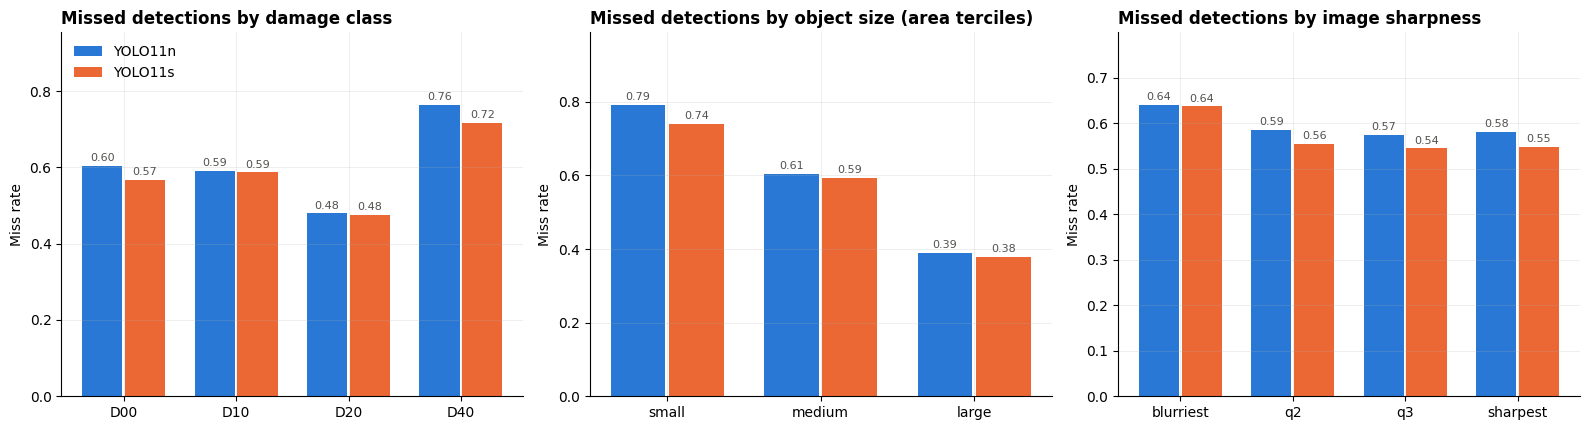

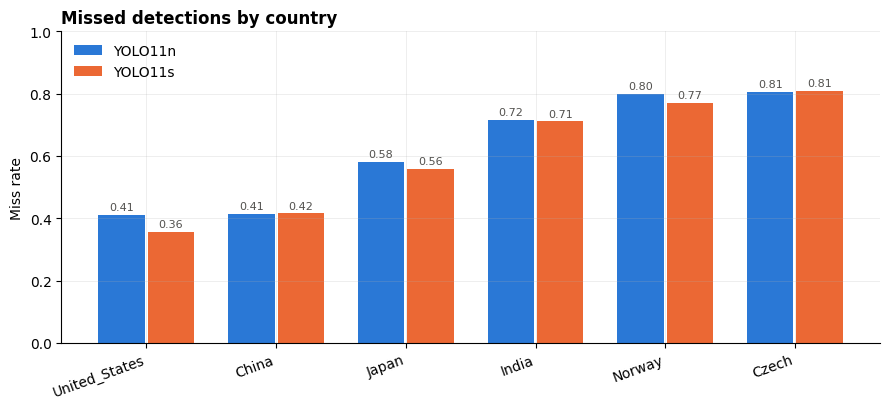

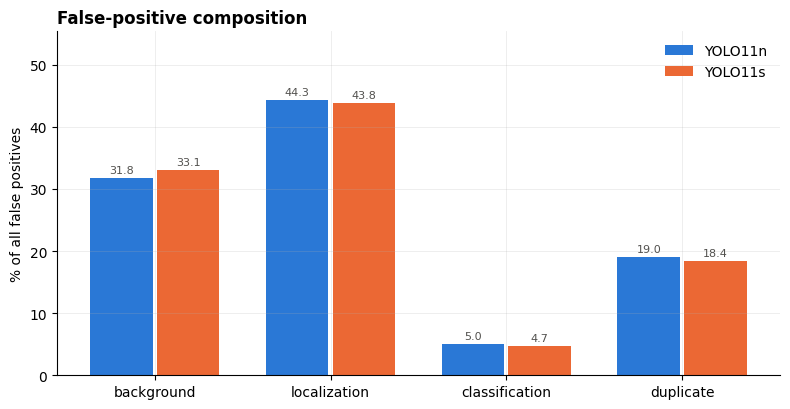

figures saved to /content/drive/MyDrive/RDD2022_Project/member2_runs/figures

total false positives per model:
model
YOLO11n    2835
YOLO11s    2875


In [20]:
import matplotlib.pyplot as plt
C = {'YOLO11n': '#2a78d6', 'YOLO11s': '#eb6834'}
plt.rcParams.update({'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.grid': True, 'grid.alpha': .25, 'grid.linewidth': .6,
                     'font.size': 10, 'figure.facecolor': 'white'})

def grouped(ax, tbl, title, ylab='Miss rate', cap=1.0, fmt='%.2f'):
    x = np.arange(len(tbl)); w = 0.38
    for k, mdl in enumerate(['YOLO11n', 'YOLO11s']):
        b = ax.bar(x + (k - .5) * w, tbl[mdl], w * .94, label=mdl, color=C[mdl])
        ax.bar_label(b, fmt=fmt, fontsize=8, padding=2, color='#52514e')
    ax.set_xticks(x); ax.set_xticklabels(tbl.index, rotation=0)
    ax.set_title(title, loc='left', fontweight='semibold')
    ax.set_ylabel(ylab); ax.set_ylim(0, min(cap, tbl.values.max() * 1.25))

fig, axes = plt.subplots(1, 3, figsize=(16, 4.4))
grouped(axes[0], slices['cls'], 'Missed detections by damage class')
grouped(axes[1], slices['area_bin'], 'Missed detections by object size (area terciles)')
grouped(axes[2], slices['blur_q'], 'Missed detections by image sharpness')
axes[0].legend(frameon=False, loc='upper left')
fig.tight_layout(); fig.savefig(FIGS / 'B8_miss_rate_slices.png', dpi=160); plt.show()

fig, ax = plt.subplots(figsize=(9, 4.2))
t = slices['country'].sort_values('YOLO11s')
grouped(ax, t, 'Missed detections by country')
ax.legend(frameon=False, loc='upper left'); plt.xticks(rotation=20, ha='right')
fig.tight_layout(); fig.savefig(FIGS / 'B8_miss_by_country.png', dpi=160); plt.show()

fig, ax = plt.subplots(figsize=(8, 4.2))
order = ['FP_background', 'FP_localization', 'FP_classification', 'FP_duplicate']
t = fp_pct.reindex(order).fillna(0)
grouped(ax, t, 'False-positive composition',
        ylab='% of all false positives', cap=100, fmt='%.1f')
ax.set_xticklabels([o.replace('FP_', '') for o in order])
ax.legend(frameon=False, loc='upper right')
fig.tight_layout(); fig.savefig(FIGS / 'B8_fp_taxonomy.png', dpi=160); plt.show()

print('figures saved to', FIGS)
print('\ntotal false positives per model:')
print(D[D.kind != 'TP'].groupby('model').size().to_string())

In [14]:
with zipfile.ZipFile(ZIP) as z:
    names = z.namelist(); top = names[0].split('/')[0]
    root = top + '/' if all(n.startswith(top + '/') for n in names) else ''
    todo = [n for n in names if not n.endswith('/')
            and n[len(root):].startswith(('cross_country_', 'dataset'))]
    for n in todo:
        out = DATA / n[len(root):]
        out.parent.mkdir(parents=True, exist_ok=True)
        out.write_bytes(z.read(n))
print(sorted(n[len(root):] for n in todo))

['cross_country_test.txt', 'cross_country_train.txt', 'cross_country_val.txt', 'dataset.yaml', 'dataset_cross_country.yaml']


In [26]:
CFG = DRIVE / 'member2_configs'
name_set = lambda p: {Path(l).name for l in Path(p).read_text().split() if l.strip()}
train8k = name_set(CFG / 'subset_train_8k.txt')
cctrain = name_set(CFG / 'subset_cc_train_8k.txt')
us_test   = [Path(l).name for l in (DATA / 'cross_country_test.txt').read_text().split() if l.strip()]
nonus_val = [Path(l).name for l in (DATA / 'cross_country_val.txt').read_text().split() if l.strip()]
print('US test  ∩ B5 train :', len(set(us_test)   & train8k), 'of', len(us_test))
print('US test  ∩ CC train :', len(set(us_test)   & cctrain))
print('nonUS val ∩ B5 train:', len(set(nonus_val) & train8k), 'of', len(nonus_val))
print('nonUS val ∩ CC train:', len(set(nonus_val) & cctrain))

US test  ∩ B5 train : 1001 of 4805
US test  ∩ CC train : 0
nonUS val ∩ B5 train: 1044 of 4964
nonUS val ∩ CC train: 0


In [17]:
seen = train8k | cctrain
us_clean    = [f for f in us_test   if f not in seen]
nonus_clean = [f for f in nonus_val if f not in seen]
print(f'clean US test {len(us_clean)} | clean non-US {len(nonus_clean)}')

with zipfile.ZipFile(ZIP) as z:
    names = z.namelist(); top = names[0].split('/')[0]
    root = top + '/' if all(n.startswith(top + '/') for n in names) else ''
    zmap = {Path(n).name: n for n in names if n[len(root):].startswith('images/')}
    missing = [f for f in set(us_clean) | set(nonus_clean)
               if not (DATA / zmap[f][len(root):]).exists()]
    print(f'extracting {len(missing)}...')
    for f in missing:
        out = DATA / zmap[f][len(root):]
        out.parent.mkdir(parents=True, exist_ok=True)
        out.write_bytes(z.read(zmap[f]))

loc = lambda f: str(DATA / zmap[f][len(root):])
EVALS = {}
for tag, lst in [('US', us_clean), ('nonUS', nonus_clean)]:
    (DATA / f'eval_{tag}.txt').write_text('\n'.join(loc(f) for f in lst) + '\n')
    y = DATA / f'eval_{tag}.yaml'
    y.write_text(f"path: {DATA}\ntrain: {DATA}/eval_{tag}.txt\nval: {DATA}/eval_{tag}.txt\n"
                 f"test: {DATA}/eval_{tag}.txt\nnames:\n  0: D00\n  1: D10\n  2: D20\n  3: D40\n")
    EVALS[tag] = str(y)

MODELS = {'all-country 8k (B5)': BEST['YOLO11s'],
          'non-US 8k (CC)':      DRIVE / 'member2_runs/det-cc-8k-01/weights/best.pt'}
assert all(Path(v).exists() for v in MODELS.values()), MODELS

grid = {}
for mname, w in MODELS.items():
    m = YOLO(str(w))
    for tag, yml in EVALS.items():
        r = m.val(data=yml, split='test', imgsz=IMGSZ, batch=16, conf=0.001, iou=0.7,
                  workers=WORKERS, device=0, plots=False, verbose=False,
                  project='/content/runs', name=f'x-{tag}', exist_ok=True)
        grid[(mname, tag)] = round(float(r.box.map50), 4)
        print(mname, tag, grid[(mname, tag)])

cc2 = pd.Series(grid).unstack()
cc2['gap_nonUS_to_US'] = (cc2['US'] - cc2['nonUS']).round(4)
cc2.to_csv(TABLES / 'B7_cross_country_2x2.csv')
print('\nmAP@0.50\n', cc2.to_string())

clean US test 3804 | clean non-US 3920
extracting 6259...
Ultralytics 8.4.117 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
YOLO11s summary (fused): 101 layers, 9,414,348 parameters, 0 gradients, 21.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1983.9±593.5 MB/s, size: 67.9 KB)
val: Scanning /content/rdd2022_yolo_coco_full_labeled/labels/test... 3804 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 3804/3804 1.5Kit/s 2.5s
val: New cache created: /content/rdd2022_yolo_coco_full_labeled/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 238/238 8.2it/s 29.0s
                   all       3804       8731      0.527      0.509      0.503      0.269
Speed: 0.7ms preprocess, 4.3ms inference, 0.0ms loss, 0.7ms postprocess per image
all-country 8k (B5) US 0.5032
Ultralytics 8.4.117 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
val: Fast image access ✅ (ping: 0.0±0.0 m

In [33]:
st = lambda f: Path(f).stem
val_split = {p.stem for p in (DATA / 'labels' / 'val').glob('*.txt')}
print('official val:', len(val_split))
print('us_clean    ∩ official val:', sum(st(f) in val_split for f in us_clean),    'of', len(us_clean))
print('nonus_clean ∩ official val:', sum(st(f) in val_split for f in nonus_clean), 'of', len(nonus_clean))

official val: 5714
us_clean    ∩ official val: 720 of 3804
nonus_clean ∩ official val: 754 of 3920


In [34]:
import random
excl = {st(f) for f in train8k} | {st(f) for f in cctrain} | val_split

us_eval = [f for f in us_test if st(f) not in excl]
pool    = [Path(l).name for l in (DATA / 'cross_country_train.txt').read_text().split() if l.strip()]
nonus_pool = [f for f in pool if st(f) not in excl]
nonus_eval = sorted(random.Random(42).sample(sorted(nonus_pool), min(len(us_eval), len(nonus_pool))))
print(f'strict US {len(us_eval)} | strict non-US {len(nonus_eval)} (pool {len(nonus_pool)})')

with zipfile.ZipFile(ZIP) as z:
    names = z.namelist(); top = names[0].split('/')[0]
    root = top + '/' if all(n.startswith(top + '/') for n in names) else ''
    zmap = {Path(n).name: n for n in names if n[len(root):].startswith('images/')}
    missing = [f for f in set(us_eval) | set(nonus_eval) if not (DATA / zmap[f][len(root):]).exists()]
    print(f'extracting {len(missing)}...')
    for f in missing:
        out = DATA / zmap[f][len(root):]
        out.parent.mkdir(parents=True, exist_ok=True)
        out.write_bytes(z.read(zmap[f]))

loc = lambda f: str(DATA / zmap[f][len(root):])
EV = {}
for tag, lst in [('US', us_eval), ('nonUS', nonus_eval)]:
    (DATA / f'strict_{tag}.txt').write_text('\n'.join(loc(f) for f in lst) + '\n')
    y = DATA / f'strict_{tag}.yaml'
    y.write_text(f"path: {DATA}\ntrain: {DATA}/strict_{tag}.txt\nval: {DATA}/strict_{tag}.txt\n"
                 f"test: {DATA}/strict_{tag}.txt\nnames:\n  0: D00\n  1: D10\n  2: D20\n  3: D40\n")
    EV[tag] = str(y)

MODELS = {'all-country 8k (B5)': BEST['YOLO11s'],
          'non-US 8k (CC)':      DRIVE / 'member2_runs/det-cc-8k-01/weights/best.pt'}
g = {}
for mn, w in MODELS.items():
    m = YOLO(str(w))
    for tag, yml in EV.items():
        r = m.val(data=yml, split='test', imgsz=IMGSZ, batch=16, conf=0.001, iou=0.7,
                  workers=WORKERS, device=0, plots=False, verbose=False,
                  project='/content/runs', name=f's-{tag}', exist_ok=True)
        g[(mn, tag)] = round(float(r.box.map50), 4)
        print(mn, tag, g[(mn, tag)])

strict = pd.Series(g).unstack()
strict['gap_nonUS_to_US'] = (strict['US'] - strict['nonUS']).round(4)
strict.to_csv(TABLES / 'B7_cross_country_2x2_strict.csv')
print('\nmAP@0.50 (strict: no train, no selection overlap)\n', strict.to_string())

strict US 3084 | strict non-US 3084 (pool 13077)
extracting 2372...
Ultralytics 8.4.117 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
YOLO11s summary (fused): 101 layers, 9,414,348 parameters, 0 gradients, 21.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1925.0±592.9 MB/s, size: 70.5 KB)
val: Scanning /content/rdd2022_yolo_coco_full_labeled/labels/test... 3084 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 3084/3084 1.5Kit/s 2.0s
val: New cache created: /content/rdd2022_yolo_coco_full_labeled/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 193/193 8.4it/s 22.9s
                   all       3084       7103      0.534      0.503      0.506      0.273
Speed: 0.6ms preprocess, 4.3ms inference, 0.0ms loss, 0.7ms postprocess per image
all-country 8k (B5) US 0.5064
Ultralytics 8.4.117 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
val: Fast image access ✅ (ping:

Densest multi-damage scene         Norway__Norway_006556
Smallest pothole (D40)             Norway__Norway_007540
Darkest image (2+ targets)           Japan__Japan_010449
Norway, highest resolution         Norway__Norway_000090
Most background false positives      India__India_008337


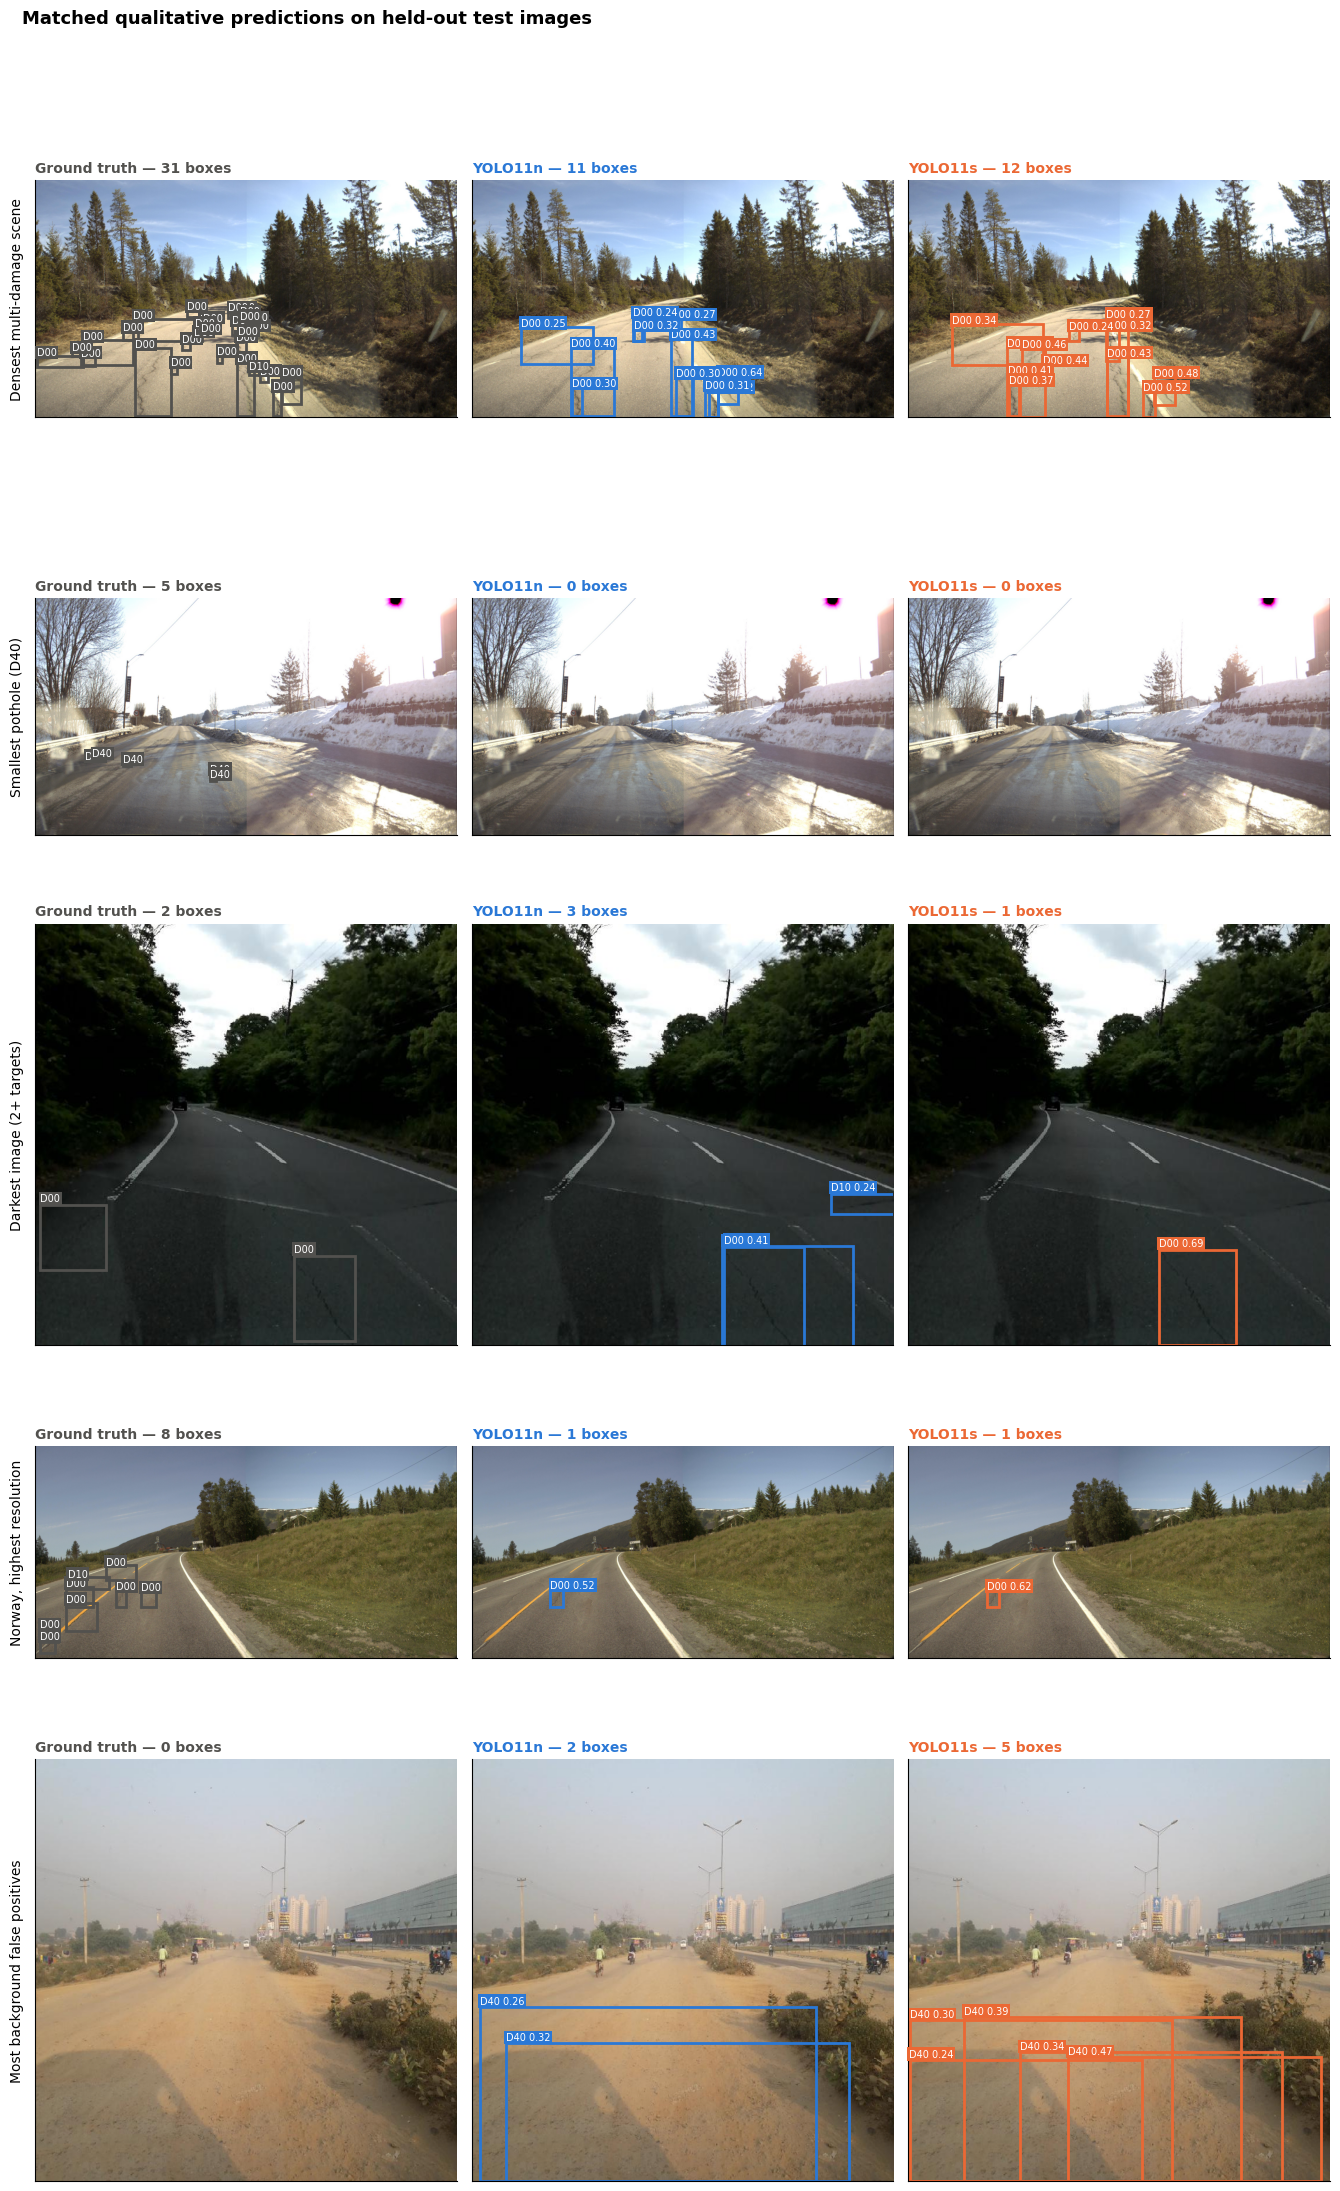

saved to /content/drive/MyDrive/RDD2022_Project/member2_runs/figures/B8_qualitative_panels.png


In [18]:
import matplotlib.patches as mp
from PIL import Image

Gn = G[G.model == 'YOLO11n']
cnt = Gn.groupby('stem').size()
sel = {
    'Densest multi-damage scene':        cnt.idxmax(),
    'Smallest pothole (D40)':            Gn[Gn.cls == 'D40'].nsmallest(1, 'rel_area').stem.iloc[0],
    'Darkest image (2+ targets)':        Gn[Gn.stem.isin(cnt[cnt >= 2].index)].nsmallest(1, 'brightness_mean').stem.iloc[0],
    'Norway, highest resolution':        Gn[Gn.country == 'Norway'].nlargest(1, 'resolution_mpx').stem.iloc[0],
    'Most background false positives':   D[(D.model == 'YOLO11s') & (D.kind == 'FP_background')].groupby('stem').size().idxmax(),
}
print(pd.Series(sel).to_string())

stems_sel = list(sel.values())
preds = {}
for name, w in BEST.items():
    m = YOLO(str(w))
    for s, r in zip(stems_sel, m.predict([paths[s] for s in stems_sel], imgsz=IMGSZ,
                                         conf=conf_star[name], iou=0.7, device=0, verbose=False)):
        preds[(name, s)] = list(zip(r.boxes.cls.int().tolist(), r.boxes.conf.tolist(), r.boxes.xyxy.tolist()))

COL = {'Ground truth': '#52514e', 'YOLO11n': '#2a78d6', 'YOLO11s': '#eb6834'}
fig, axes = plt.subplots(len(sel), 3, figsize=(13.5, 4.4 * len(sel)))
for i, (label, s) in enumerate(sel.items()):
    img = Image.open(paths[s])
    for j, col in enumerate(COL):
        ax = axes[i, j]
        ax.imshow(img); ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
        boxes = [(gg[0], None, gg[1:5]) for gg in gt[s]] if col == 'Ground truth' else preds[(col, s)]
        for c, cf, b in boxes:
            ax.add_patch(mp.Rectangle((b[0], b[1]), b[2]-b[0], b[3]-b[1],
                                      fill=False, lw=2, edgecolor=COL[col]))
            ax.text(b[0], max(b[1] - 5, 12), NAMES[c] if cf is None else f'{NAMES[c]} {cf:.2f}',
                    fontsize=7, color='white',
                    bbox=dict(facecolor=COL[col], edgecolor='none', pad=1.2))
        ax.set_title(f'{col} — {len(boxes)} boxes', fontsize=10, loc='left',
                     color=COL[col], fontweight='semibold')
    axes[i, 0].set_ylabel(label, fontsize=10, labelpad=8)

fig.suptitle('Matched qualitative predictions on held-out test images', fontsize=13,
             fontweight='semibold', x=0.02, ha='left', y=0.999)
fig.tight_layout(rect=[0, 0, 1, 0.99])
fig.savefig(FIGS / 'B8_qualitative_panels.png', dpi=150, bbox_inches='tight')
plt.show()
print('saved to', FIGS / 'B8_qualitative_panels.png')